# Employee Attrition Analysis (HR Analytics)

# Objective:
## Analyze employee data to identify patterns and key factors contributing to employee attrition.

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


## Load Dataset

In [2]:
df = pd.read_csv("HR_Attrition_Compressed.csv")
df.head()


,Attrition,Age,Department,MonthlyIncome,JobRole,YearsAtCompany,TotalWorkingYears,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance,OverTime,Education,Gender,Attrition_Flag,IncomeGroup,ExperienceGroup
0,Yes,41,Sales,5993,Sales Executive,6,8,4,2,1,Yes,2,Female,1,Upper-Mid Income,6-10 Years
1,No,49,Research & Development,5130,Research Scientist,10,10,2,3,3,No,1,Male,0,Upper-Mid Income,6-10 Years
2,Yes,37,Research & Development,2090,Laboratory Technician,0,7,3,4,3,Yes,2,Male,1,Low Income,6-10 Years
3,No,33,Research & Development,2909,Research Scientist,8,8,3,4,3,Yes,4,Female,0,Low Income,6-10 Years
4,No,27,Research & Development,3468,Laboratory Technician,2,6,2,1,3,No,1,Male,0,Lower-Mid Income,6-10 Years


# Basic Data Understanding

In [3]:
df.shape
df.info()
df.describe()
df['Attrition'].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Attrition                1470 non-null   object
 1   Age                      1470 non-null   int64 
 2   Department               1470 non-null   object
 3   MonthlyIncome            1470 non-null   int64 
 4   JobRole                  1470 non-null   object
 5   YearsAtCompany           1470 non-null   int64 
 6   TotalWorkingYears        1470 non-null   int64 
 7   JobSatisfaction          1470 non-null   int64 
 8   EnvironmentSatisfaction  1470 non-null   int64 
 9   WorkLifeBalance          1470 non-null   int64 
 10  OverTime                 1470 non-null   object
 11  Education                1470 non-null   int64 
 12  Gender                   1470 non-null   object
 13  Attrition_Flag           1470 non-null   int64 
 14  IncomeGroup              1470 non-null  

Attrition
No     1233
Yes     237
Name: count, dtype: int64

# `Calculate Attrition Rate (Very Important)

In [4]:
attrition_rate = df['Attrition'].value_counts(normalize=True) * 100
attrition_rate


Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

# Analyze Attrition by Department

In [10]:
dept_attrition = pd.crosstab(df['Department'], df['Attrition'], normalize='index') * 100
dept_attrition


Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


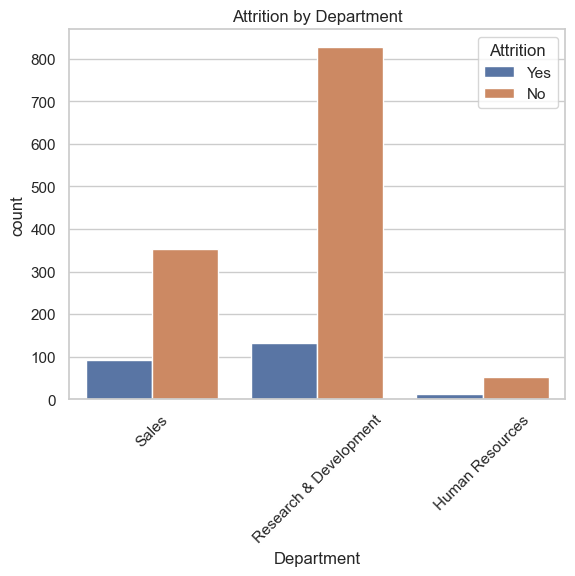

In [8]:
sns.countplot(x='Department', hue='Attrition', data=df)
plt.xticks(rotation=45)
plt.title("Attrition by Department")
plt.show()


# Salary vs Attrition

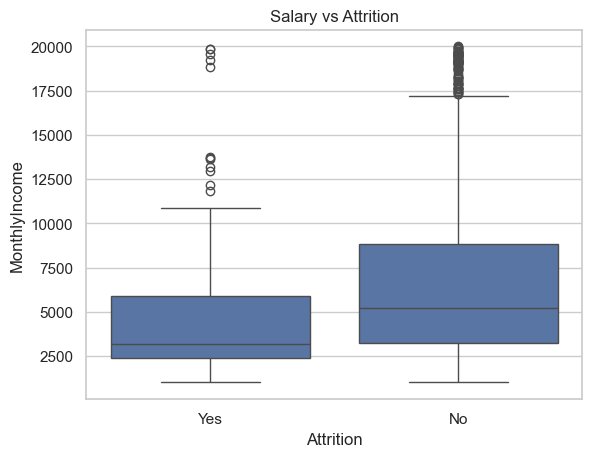

In [11]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Salary vs Attrition")
plt.show()


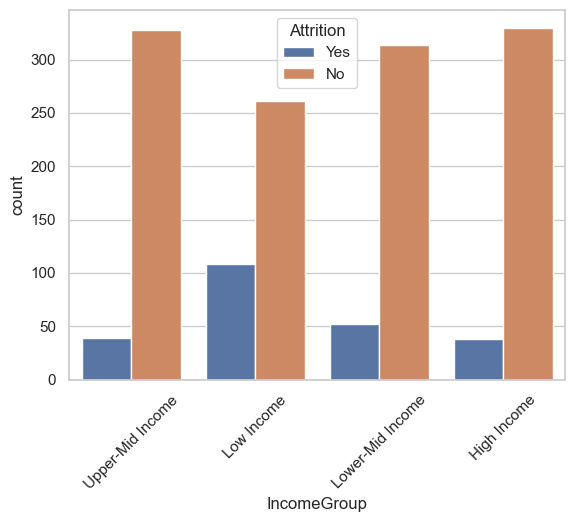

In [12]:
sns.countplot(x='IncomeGroup', hue='Attrition', data=df)
plt.xticks(rotation=45)
plt.show()


# Experience vs Attrition

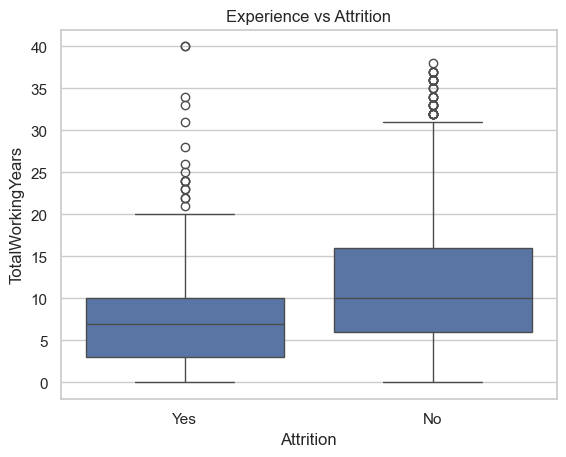

In [13]:
sns.boxplot(x='Attrition', y='TotalWorkingYears', data=df)
plt.title("Experience vs Attrition")
plt.show()


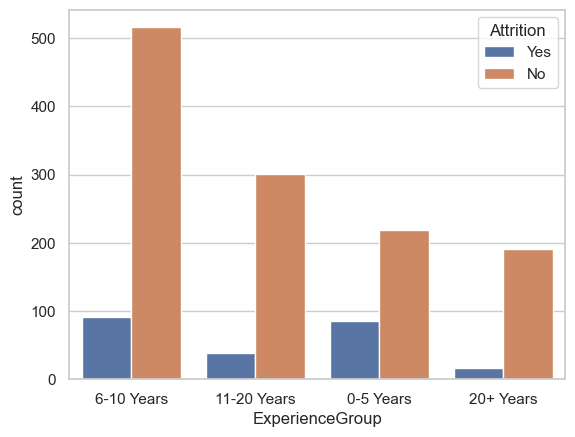

In [14]:
sns.countplot(x='ExperienceGroup', hue='Attrition', data=df)
plt.show()


# Overtime Impact

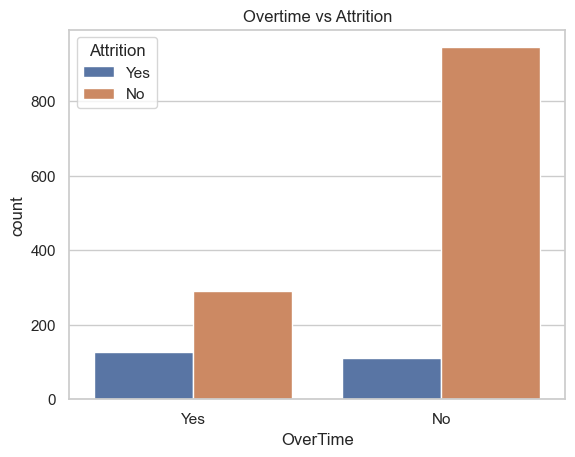

In [15]:
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title("Overtime vs Attrition")
plt.show()


In [16]:
pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100


Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


# Calculate Overall Attrition Rate

In [17]:
total_employees = len(df)
total_attrition = df['Attrition'].value_counts()['Yes']

attrition_rate = (total_attrition / total_employees) * 100

print("Total Employees:", total_employees)
print("Employees Left:", total_attrition)
print("Attrition Rate:", round(attrition_rate,2), "%")


Total Employees: 1470
Employees Left: 237
Attrition Rate: 16.12 %


Analyze Attrition by Department

In [18]:
dept_analysis = pd.crosstab(df['Department'], df['Attrition'])
dept_analysis


Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


In [19]:
pd.crosstab(df['Department'], df['Attrition'], normalize='index') * 100


Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


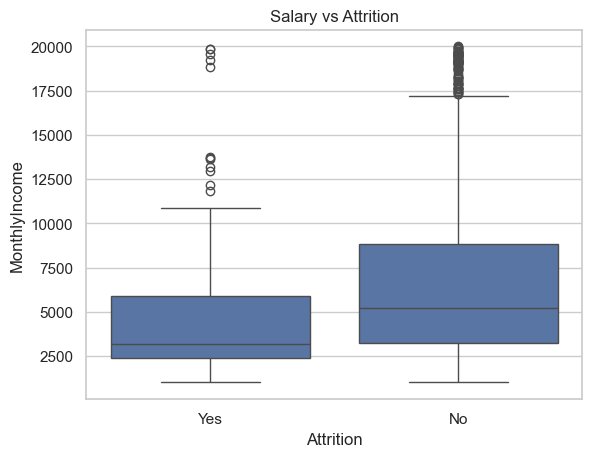

In [20]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Salary vs Attrition")
plt.show()


In [21]:
pd.crosstab(df['IncomeGroup'], df['Attrition'], normalize='index') * 100


Attrition,No,Yes
IncomeGroup,,
High Income,89.673913,10.326087
Low Income,70.731707,29.268293
Lower-Mid Income,85.792350,14.207650
Upper-Mid Income,89.373297,10.626703


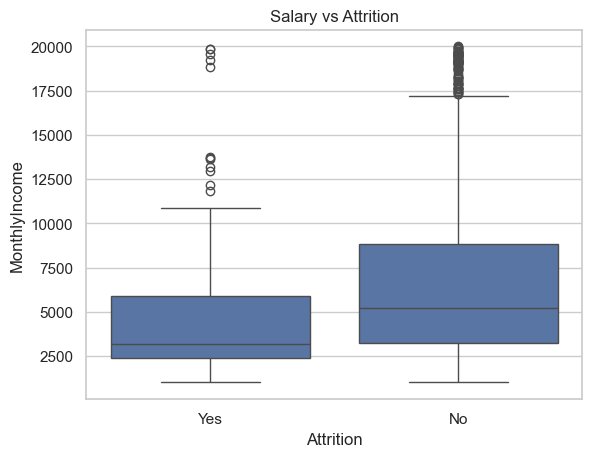

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Salary vs Attrition")
plt.show()


In [23]:
pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100


Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


# “The top reason for employee attrition is overtime combined with early-career employees earning lower income.”